In [ ]:
import re
import pandas as pd
import torch
import numpy as np
from tqdm import tqdm
from torch.nn.functional import pad
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import matplotlib.colors as mcolors

In [2]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
from transformers import LlamaForCausalLM, LlamaTokenizerFast

import argparse
import pickle
import os
import json
import pandas as pd

#model_id = "unsloth/Meta-Llama-3.1-8B-bnb-4bit"

model_id = "gpt2-large"
device='cuda:1'
if "Llama" in model_id:
    #model = LlamaForCausalLM.from_pretrained(model_id, device_map="auto")
    tokenizer = LlamaTokenizerFast.from_pretrained(model_id)
    start_of_sentence='<|begin_of_text|>'
if "gpt2" in model_id:
    #model = GPT2LMHeadModel.from_pretrained(model_id).to(device)
    tokenizer = GPT2TokenizerFast.from_pretrained(model_id)
    start_of_sentence =" "

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [4]:
import os
os.chdir("/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/")
os.getcwd()

'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling'

In [5]:
from perplexity_labelling import compute_p1, compute_p2, compute_p3
from utils import swap_speaker_tokens_with_metadata, get_shuffled_dialog_data, reorder_tokens

[nltk_data] Downloading package punkt to /u/sebono/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /u/sebono/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
import numpy as np
import re
import pandas as pd

In [7]:
tri_pilot_df = pd.read_csv("/u/sebono/conversational_dominance/data/processed/triadic-pilot/conversations.csv")
tri_pilot_df

,file_name,file_content
0,p08_s03,<SPK1> Oh. Yay. It's story time. <SPK2> Hello....
1,p10_s02,<SPK3> Hello. <SPK2> Hi. <SPK0> Hi. <SPK3> You...
2,p09_s04,<SPK2> I will now turn on a start audio video ...
3,p09_s05,"<SPK0> Uh, and how did they turned on? <SPK3> ..."
4,p12_s02,<SPK2> Hello. <SPK1> Hello. <SPK0> Hello. <SPK...
...,...,...
67,p03_s05,<SPK2> [Foreign Language 00:00:57] <SPK1> [For...
68,p11_s05,<SPK0> (laughs) So funny. <SPK2> Hello. <SPK1>...
69,p12_s00,"<SPK2> Hello. <SPK1> Hi. Hi, Jibo. <SPK0> Hi, ..."
70,p10_s00,<SPK2> Hello. I am now on story time mode. My ...


In [8]:
file_name = "p08_s03"
dialog = tri_pilot_df[tri_pilot_df['file_name'] == file_name]['file_content'][0]

In [9]:
pattern = r'<(?:SPK[0-9]|MOD)>'
dialog_lines = re.sub(r"[\[\(].*?[\]\)]", "", dialog).replace("<", "\n<").split("\n")[1:]
matches = [f"{start_of_sentence}{match}" for match in re.findall(pattern, f"{start_of_sentence}".join(dialog_lines))]
token_list = [tokenizer(token, return_tensors="pt").input_ids[0] for token in dialog_lines]
encodings = tokenizer(f"{start_of_sentence}".join(dialog_lines), return_tensors="pt")
assert np.cumsum([len(token) for token in token_list])[-1] == encodings.input_ids[0].shape

Token indices sequence length is longer than the specified maximum sequence length for this model (7322 > 1024). Running this sequence through the model will result in indexing errors


In [10]:
assert len(matches) == len(dialog_lines)

In [11]:
from utils import correlation_heatmap

In [12]:
all_data = pd.DataFrame({})

In [13]:
all_data = pd.DataFrame({})
for p_name in ['p1','p2','p3']:
    file_name_sample = f'/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/dataset_perplexity_results/triadic-pilot_{p_name}_{model_id}/dominance_scores_{file_name}.pkl'
    with open(file_name_sample, 'rb') as f:
        all_data[f"{p_name}"] = pickle.load(f)[file_name]

In [14]:
from utils import correlation_heatmap, correlation_heatmap, compute_dominance_per_spk, rolling_kde_heatmap_with_turns, remove_match_prefix_ppl, compute_graph_perplexity, display_turns_colored_by_kde

In [15]:
all_data

,p1,p2,p3
0,NaN,NaN,5.295516
1,7.840308,7.840308,4.902964
2,5.805719,6.823014,3.548398
3,6.631710,6.759245,1.984670
4,1.512527,5.447566,1.509352
...,...,...,...
7317,1.567797,0.472805,3.298620
7318,0.002514,0.379202,2.829936
7319,2.959905,0.809838,3.467941
7320,0.124619,0.705598,3.115352


In [16]:
# BEFORE
col_1 = ["p1","p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data)

In [17]:
fig_corr

In [18]:
from utils import remove_match_prefix_ppl, display_colored_sentences, extract_tokens_and_ppls_by_turn_indices, correlation_heatmap

In [19]:
filtered_tokens_p1, filtered_ppl_p1, filtered_encodings_p1, filtered_matches_p1 = remove_match_prefix_ppl(token_list, all_data['p1'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p1])[-1], len(filtered_tokens_p1)

In [20]:
filtered_tokens_p2, filtered_ppl_p2, filtered_encodings_p2, filtered_matches_p2 = remove_match_prefix_ppl(token_list, all_data['p2'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p2])[-1], len(filtered_tokens_p2)

In [21]:
filtered_tokens_p3, filtered_ppl_p3, filtered_encodings_p3, filtered_matches_p3 = remove_match_prefix_ppl(token_list, all_data['p3'], matches, tokenizer, min_len=1)
assert np.cumsum([len(token) for token in filtered_tokens_p3])[-1], len(filtered_tokens_p3)

In [22]:
assert len(filtered_tokens_p1) == len(filtered_tokens_p2)
assert len(filtered_tokens_p1) == len(filtered_tokens_p3)

assert filtered_encodings_p1 == filtered_encodings_p2
assert filtered_encodings_p1 == filtered_encodings_p3
filtered_encodings = filtered_encodings_p1

In [23]:
# BEFORE
all_data_filtered = pd.DataFrame({"p1":filtered_ppl_p1, "p2":filtered_ppl_p2, "p3":filtered_ppl_p3})
col_1 = ["p2","p3"]
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_1,all_data_filtered)

In [24]:
fig_corr

In [25]:
# Get turn indices for SPK0 (kid)
start_turn=0
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p2)[start_turn:end_turn] == f"{start_of_sentence}<SPK0>")[0]

# Get filtered tokens and PPLs
filtered_tokens_p2_spk0, filtered_ppl_p2_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p2, filtered_ppl_p2
)

In [26]:
# Get turn indices for SPK0 (kid)
start_turn=0
end_turn=-1
idx_spk0 = start_turn + np.where(np.asarray(filtered_matches_p3)[start_turn:end_turn] == f"{start_of_sentence}<SPK0>")[0]

# Get filtered tokens and PPLs
filtered_tokens_p3_spk0, filtered_ppl_p3_spk0 = extract_tokens_and_ppls_by_turn_indices(
    idx_spk0, filtered_tokens_p3, filtered_ppl_p3
)

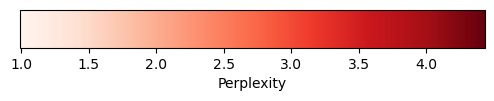

In [27]:
display_colored_sentences(filtered_tokens_p3_spk0, filtered_ppl_p3_spk0, tokenizer)

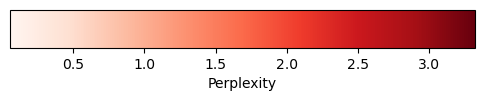

In [28]:
display_colored_sentences(filtered_tokens_p2_spk0, filtered_ppl_p2_spk0, tokenizer)

### Annotations

In [30]:
import os
os.chdir("/u/sebono/conversational_dominance/notebooks/information_exchange_labelling/")
print(os.getcwd())

from utils import (
    # VISUALIZATION
    rolling_kde_heatmap_with_turns,
    display_turns_colored_by_kde,
    compute_graph_perplexity,
    correlation_heatmap,
    # HELPERS
    compute_dominance_per_spk,
    compute_significance,
    expand_multiple_ppl_by_token,
    remove_match_prefix_ppl,
    assign_words_to_bins
)

/u/sebono/conversational_dominance/notebooks/information_exchange_labelling


In [31]:
annotation_file = f"/u/sebono/conversational_dominance/data/processed/triadic-pilot/annotation_files/childs-joint-engagement-with-parent/aggregated_annotation_files.csv"

In [32]:
annotations = pd.read_csv(annotation_file)
annotations_dataset = annotations[annotations['uniq_vid_clip'].str.startswith(file_name)]
annotations_dataset.head()

,Unnamed: 0,Label-Name,NAN,Start-Timestamp,Start-Timestamp(sec),End-Timestamp,End-Timestamp(sec),Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
9256,0,p08-child (joint-engagement-wt-parent),NaN,00:00:00.000,0.0,00:00:05.000,5.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-0.0,NaN,NaN
9257,1,p08-child (joint-engagement-wt-parent),NaN,00:00:05.000,5.0,00:00:10.000,10.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-5.0,NaN,NaN
9258,2,p08-child (joint-engagement-wt-parent),NaN,00:00:10.000,10.0,00:00:15.000,15.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-10.0,NaN,NaN
9259,3,p08-child (joint-engagement-wt-parent),NaN,00:00:15.000,15.0,00:00:20.000,20.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-15.0,NaN,NaN
9260,4,p08-child (joint-engagement-wt-parent),NaN,00:00:20.000,20.0,00:00:25.000,25.0,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-20.0,NaN,NaN


In [33]:
conversation_dataset_file = f'/u/sebono/conversational_dominance/data/external/triadic-pilot/{file_name}_REV.csv'
conversation_dataset = pd.read_csv(conversation_dataset_file)
conversation_dataset

,Unnamed: 0,timestamp,real_time,speaker,content
0,0,00:00:00,2021-06-23 09:31:47,Parent,Oh. Yay. It's story time.
1,1,00:00:07,2021-06-23 09:31:54,Robot,Hello.
2,2,00:00:07,2021-06-23 09:31:54,Parent,Hi. Hi Jibo.
3,3,00:00:10,2021-06-23 09:31:57,Robot,I am not on Story Time mode. My camera will no...
4,4,00:00:16,2021-06-23 09:32:03,Parent,Okay.
...,...,...,...,...,...
458,458,00:28:35,2021-06-23 10:00:22,Robot,And please complete the story survey with your...
459,459,00:28:38,2021-06-23 10:00:25,Parent,"All right, you ready to make your survey?"
460,460,00:28:39,2021-06-23 10:00:26,Robot,Thank you. Bye bye.
461,461,00:28:40,2021-06-23 10:00:27,Child,Bye bye.


In [34]:
assert len(matches) == len(conversation_dataset['content'])

In [35]:
conversation_dataset["tokens"] = [token.detach().numpy() for token in filtered_tokens_p1]
conversation_dataset[conversation_dataset['speaker']=='Child']

,Unnamed: 0,timestamp,real_time,speaker,content,tokens
7,7,00:00:32,2021-06-23 09:32:19,Child,The Jibo book.,"[383, 449, 26762, 1492, 13, 220]"
9,9,00:00:40,2021-06-23 09:32:27,Child,Yeah.,"[9425, 13, 220]"
15,15,00:01:27,2021-06-23 09:33:14,Child,A.,"[317, 13, 220]"
17,17,00:01:29,2021-06-23 09:33:16,Child,B.,"[347, 13, 220]"
19,19,00:01:31,2021-06-23 09:33:18,Child,C.,"[327, 13, 220]"
...,...,...,...,...,...,...
448,448,00:28:08,2021-06-23 09:59:55,Child,[inaudible 00:28:08].,"[764, 220]"
450,450,00:28:14,2021-06-23 10:00:01,Child,Another one.,"[6023, 530, 13, 220]"
455,455,00:28:30,2021-06-23 10:00:17,Child,[crosstalk 00:28:30] Bye bye.,"[220, 47843, 33847, 13, 220]"
457,457,00:28:33,2021-06-23 10:00:20,Child,Bye bye.,"[47843, 33847, 13, 220]"


In [36]:
import pandas as pd

#df = conversation_dataset[conversation_dataset['speaker']=='Child'].copy()
df = conversation_dataset.copy()
df["start"] = pd.to_timedelta(df["timestamp"]).dt.total_seconds()
df["stop"] = df["start"].shift(-1)
df.loc[df.index[-1], "stop"] = df["start"].iloc[-1] + 1
df = df[["start", "stop", "speaker", "content", "tokens"]]

In [37]:
df

,start,stop,speaker,content,tokens
0,0.0,7.0,Parent,Oh. Yay. It's story time.,"[3966, 13, 575, 323, 13, 632, 338, 1621, 640, ..."
1,7.0,7.0,Robot,Hello.,"[18435, 13, 220]"
2,7.0,10.0,Parent,Hi. Hi Jibo.,"[15902, 13, 15902, 449, 26762, 13, 220]"
3,10.0,16.0,Robot,I am not on Story Time mode. My camera will no...,"[314, 716, 407, 319, 8362, 3862, 4235, 13, 201..."
4,16.0,16.0,Parent,Okay.,"[16805, 13, 220]"
...,...,...,...,...,...
458,1715.0,1718.0,Robot,And please complete the story survey with your...,"[843, 3387, 1844, 262, 1621, 5526, 351, 534, 1..."
459,1718.0,1719.0,Parent,"All right, you ready to make your survey?","[1439, 826, 11, 345, 3492, 284, 787, 534, 5526..."
460,1719.0,1720.0,Robot,Thank you. Bye bye.,"[6952, 345, 13, 47843, 33847, 13, 220]"
461,1720.0,1720.0,Child,Bye bye.,"[47843, 33847, 13, 220]"


In [38]:
import numpy as np
import pandas as pd
import torch
from collections import defaultdict

def assign_words_to_bins(df, bin_size=5.0):
    """
    Assigns tokens to time bins based on uniform spread over the utterance duration.
    Includes utterances with 0 duration. Ensures all bins from time 0 to max stop are represented.

    Args:
        df (pd.DataFrame): DataFrame with columns ['start_time', 'end_time', 'tokens']
        bin_size (float): Size of each time bin in seconds

    Returns:
        pd.DataFrame: each row is a bin with its start/end time, decoded words, token indices, and token count
    """
    bin_tok = defaultdict(list)
    bin_ppl = defaultdict(list)
    global_token_idx = 0

    for _, row in df.iterrows():
        start = row["start"]
        stop = row["stop"]
        tokens = row["tokens"]

        if pd.isna(start) or pd.isna(stop) or tokens is None or len(tokens) == 0:
            continue

        duration = stop - start
        if duration < 0:
            continue

        # Handle 0-duration: treat as a very short utterance
        if duration == 0:
            duration = 1e-6

        # Token timing interpolation
        tok_times = np.linspace(start, stop, len(tokens) + 1)

        for i, token in enumerate(tokens):
            tok_start = tok_times[i]
            tok_end = tok_times[i + 1]

            bin_start_idx = int(np.floor(tok_start / bin_size))
            bin_end_idx = int(np.floor((tok_end - 1e-6) / bin_size))  # avoid border collision

            for b in range(bin_start_idx, bin_end_idx + 1):
                bin_tok[b].append(token)
                bin_ppl[b].append(global_token_idx + i)

        global_token_idx += len(tokens)

    # Build output DataFrame
    max_bin = int(np.ceil(df["stop"].max() / bin_size))
    all_bins = list(range(max_bin + 1))

    bins_df = pd.DataFrame([
        {
            "time_bin": b,
            "start_time": b * bin_size,
            "end_time": (b + 1) * bin_size,
            "words": tokenizer.decode(torch.tensor(bin_tok[b]), skip_special_tokens=True),
            "ppl": bin_ppl[b],
            "tokens": torch.tensor(bin_tok[b]),
            "n_tok": len(bin_tok[b])
        }
        for b in all_bins
    ])

    return bins_df

In [39]:
bins_df = assign_words_to_bins(df, bin_size=5.0)

In [40]:
bins_df

,time_bin,start_time,end_time,words,ppl,tokens,n_tok
0,0,0.0,5.0,Oh. Yay. It's story,"[0, 1, 2, 3, 4, 5, 6, 7]","[tensor(3966), tensor(13), tensor(575), tensor...",8
1,1,5.0,10.0,story time. Hello. Hi. Hi Jibo.,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[tensor(1621), tensor(640), tensor(13), tensor...",14
2,2,10.0,15.0,I am not on Story Time mode. My camera will n...,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...","[tensor(314), tensor(716), tensor(407), tensor...",19
3,3,15.0,20.0,video recording. Okay. Let's get started. N...,"[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5...","[tensor(2008), tensor(8296), tensor(13), tenso...",18
4,4,20.0,25.0,"storybooks together. If you haven't already, ...","[56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 6...","[tensor(1621), tensor(12106), tensor(1978), te...",14
...,...,...,...,...,...,...,...
341,341,1705.0,1710.0,I will now stop recording to respect your pri...,"[4931, 4932, 4933, 4934, 4935, 4936, 4937, 493...","[tensor(314), tensor(481), tensor(783), tensor...",20
342,342,1710.0,1715.0,Bye bye. I will switch back to leisure mode...,"[4951, 4952, 4953, 4954, 4955, 4956, 4957, 495...","[tensor(220), tensor(47843), tensor(33847), te...",19
343,343,1715.0,1720.0,And please complete the story survey with you...,"[4970, 4971, 4972, 4973, 4974, 4975, 4976, 497...","[tensor(843), tensor(3387), tensor(1844), tens...",30
344,344,1720.0,1725.0,Bye bye...,"[5004, 5005, 5006]","[tensor(47843), tensor(33847), tensor(986)]",3


In [41]:
combined_df = pd.concat([bins_df.reset_index(drop=True), annotations_dataset.iloc[:bins_df.shape[0]].reset_index(drop=True)], axis=1)
combined_df.iloc[0:]

,time_bin,start_time,end_time,words,ppl,tokens,n_tok,Unnamed: 0,Label-Name,NAN,...,Duration,Duration(sec),Rating_x,coder_name_x,Rating_y,coder_name_y,session_id,uniq_vid_clip,avg_rating,std_rating
0,0,0.0,5.0,Oh. Yay. It's story,"[0, 1, 2, 3, 4, 5, 6, 7]","[tensor(3966), tensor(13), tensor(575), tensor...",8,0,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-0.0,NaN,NaN
1,1,5.0,10.0,story time. Hello. Hi. Hi Jibo.,"[7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, ...","[tensor(1621), tensor(640), tensor(13), tensor...",14,1,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-5.0,NaN,NaN
2,2,10.0,15.0,I am not on Story Time mode. My camera will n...,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3...","[tensor(314), tensor(716), tensor(407), tensor...",19,2,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-10.0,NaN,NaN
3,3,15.0,20.0,video recording. Okay. Let's get started. N...,"[39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 5...","[tensor(2008), tensor(8296), tensor(13), tenso...",18,3,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-15.0,NaN,NaN
4,4,20.0,25.0,"storybooks together. If you haven't already, ...","[56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 6...","[tensor(1621), tensor(12106), tensor(1978), te...",14,4,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-20.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,341,1705.0,1710.0,I will now stop recording to respect your pri...,"[4931, 4932, 4933, 4934, 4935, 4936, 4937, 493...","[tensor(314), tensor(481), tensor(783), tensor...",20,341,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1705.0,NaN,NaN
342,342,1710.0,1715.0,Bye bye. I will switch back to leisure mode...,"[4951, 4952, 4953, 4954, 4955, 4956, 4957, 495...","[tensor(220), tensor(47843), tensor(33847), te...",19,342,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1710.0,NaN,NaN
343,343,1715.0,1720.0,And please complete the story survey with you...,"[4970, 4971, 4972, 4973, 4974, 4975, 4976, 497...","[tensor(843), tensor(3387), tensor(1844), tens...",30,343,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1715.0,NaN,NaN
344,344,1720.0,1725.0,Bye bye...,"[5004, 5005, 5006]","[tensor(47843), tensor(33847), tensor(986)]",3,344,p08-child (joint-engagement-wt-parent),NaN,...,00:00:05.000,5.0,NaN,Susanna/,NaN,Nana/,p08_s03_zoom_trimmed.txt,p08_s03_zoom_trimmed.txt-1720.0,NaN,NaN


In [42]:
cols = ['Rating_x', 'Rating_y','start_time','end_time','words']
ppl_dict = {'p1': all_data_filtered["p1"], 'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_filtered_expanded = expand_multiple_ppl_by_token(combined_df, ppl_dict, annotation_cols=cols)

In [43]:
from sklearn.decomposition import PCA
all_data_filtered_expanded.ffill(inplace=True)
X = np.column_stack((all_data_filtered_expanded["p2"],all_data_filtered_expanded["p3"]))

In [44]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



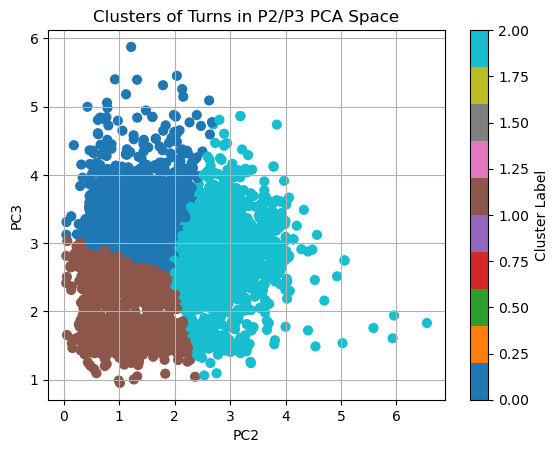

In [45]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [46]:
all_data_filtered_expanded[:50]

,token_id,p1,p2,p3,Rating_x,Rating_y,start_time,end_time,words
0,0,10.959912,6.550036,1.831498,NaN,NaN,0.0,5.0,Oh. Yay. It's story
1,1,2.840321,5.931750,1.607167,NaN,NaN,0.0,5.0,Oh. Yay. It's story
2,2,6.114723,5.957889,1.941087,NaN,NaN,0.0,5.0,Oh. Yay. It's story
3,3,2.975011,5.585029,1.758354,NaN,NaN,0.0,5.0,Oh. Yay. It's story
4,4,0.568941,5.027686,1.536653,NaN,NaN,0.0,5.0,Oh. Yay. It's story
5,5,4.047010,4.929618,2.515110,NaN,NaN,0.0,5.0,Oh. Yay. It's story
6,6,0.519421,4.528691,2.461283,NaN,NaN,0.0,5.0,Oh. Yay. It's story
7,7,10.951025,5.063885,2.747653,NaN,NaN,0.0,5.0,Oh. Yay. It's story
8,7,10.951025,5.063885,2.747653,NaN,NaN,5.0,10.0,story time. Hello. Hi. Hi Jibo.
9,8,0.334447,4.700082,2.158936,NaN,NaN,5.0,10.0,story time. Hello. Hi. Hi Jibo.


In [47]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0][:10]
    print(all_data_filtered_expanded.iloc[indices]['words'].to_numpy())


--- Cluster 0 ---
[" video recording.  Okay.  Let's get started. Now we will be reading story"
 " video recording.  Okay.  Let's get started. Now we will be reading story"
 " video recording.  Okay.  Let's get started. Now we will be reading story"
 " video recording.  Okay.  Let's get started. Now we will be reading story"
 " video recording.  Okay.  Let's get started. Now we will be reading story"
 " video recording.  Okay.  Let's get started. Now we will be reading story"
 ' book on the app. . What book did you pick?  The Jibo book. '
 ' book on the app. . What book did you pick?  The Jibo book. '
 ' book on the app. . What book did you pick?  The Jibo book. '
 ' book on the app. . What book did you pick?  The Jibo book. ']

--- Cluster 1 ---
[' story time.  Hello.  Hi. Hi Jibo. '
 ' story time.  Hello.  Hi. Hi Jibo. '
 ' story time.  Hello.  Hi. Hi Jibo. '
 ' story time.  Hello.  Hi. Hi Jibo. '
 ' story time.  Hello.  Hi. Hi Jibo. '
 ' I am not on Story Time mode. My camera will n

In [48]:
# AFTER
col_1 = ["p2","p3","p1"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_filtered_expanded)

In [49]:
fig_corr

In [50]:
def average_ppl_per_turn(df, ppl_dict, idx_col='ppl', annotation_cols=None):
    """
    For each row in df, average values from ppl_dict at indices listed in df[idx_col].

    Args:
        df (pd.DataFrame): DataFrame with a column of token indices (e.g., 'ppl').
        ppl_dict (dict): Dictionary with name -> list of PPL values.
        idx_col (str): Column in df with list of indices per turn.
        annotation_cols (List[str]): Optional columns to carry forward.

    Returns:
        pd.DataFrame: Averaged PPL values per turn, optionally with annotations.
    """
    import numpy as np
    import pandas as pd

    records = []
    for _, row in df.iterrows():
        token_ids = row[idx_col]
        if not isinstance(token_ids, list) or len(token_ids) == 0:
            continue

        record = {}
        for name, ppl_values in ppl_dict.items():
            selected = [ppl_values[i] for i in token_ids if i < len(ppl_values)]
            record[f'{name}_avg'] = np.mean(selected) if selected else None
            record['tokens'] = token_ids
            record['tok_len'] = len(token_ids)

        if annotation_cols:
            for col in annotation_cols:
                record[col] = row.get(col, None)

        records.append(record)

    return pd.DataFrame(records)

In [51]:
all_data_filtered

,p1,p2,p3
0,10.959912,6.550036,1.831498
1,2.840321,5.931750,1.607167
2,6.114723,5.957889,1.941087
3,2.975011,5.585029,1.758354
4,0.568941,5.027686,1.536653
...,...,...,...
5002,0.067808,0.369236,3.049006
5003,0.475197,0.384906,1.701610
5004,2.959905,0.809838,3.467941
5005,0.124619,0.705598,3.115352


In [52]:
cols = ['Rating_x', 'Rating_y','words','start_time','end_time', 'tokens']
ppl_dict = {'p1': all_data_filtered["p1"], 'p2': all_data_filtered["p2"], 'p3': all_data_filtered["p3"]}
all_data_filtered_expanded = average_ppl_per_turn(combined_df, ppl_dict, annotation_cols=cols)

In [53]:
all_data_filtered_expanded.dropna()

,p1_avg,tokens,tok_len,p2_avg,p3_avg,Rating_x,Rating_y,words,start_time,end_time
10,5.033718,"[tensor(508), tensor(340), tensor(338), tensor...",9,2.354133,3.058938,0.0,0.0,"who it's by? By Bill Martin,",50.0,55.0
11,4.789992,"[tensor(11), tensor(20000), tensor(290), tenso...",9,3.230496,2.897318,0.0,0.0,", Junior and John Archibald, illustrated",55.0,60.0
12,5.476334,"[tensor(18542), tensor(416), tensor(10174), te...",9,3.557562,2.804925,1.0,1.0,illustrated by Lewis Elhart. Ready? A,60.0,65.0
13,5.318196,"[tensor(317), tensor(1297), tensor(347), tenso...",9,3.937772,2.867321,1.0,1.0,A told B and B told C I'll,65.0,70.0
14,2.718074,"[tensor(1183), tensor(1826), tensor(345), tens...",9,3.803307,3.129456,1.0,1.0,'ll meet you at the top of the coconut,70.0,75.0
...,...,...,...,...,...,...,...,...,...,...
335,1.625698,"[tensor(13), tensor(220), tensor(679), tensor(...",15,0.968948,2.613087,1.0,1.0,". He is a famous tap dancer, right? Yeah.",1675.0,1680.0
336,1.946986,"[tensor(2141), tensor(345), tensor(892), tenso...",14,0.957781,3.014075,1.0,1.0,Do you think he's a famous tap dancer? The end.,1680.0,1685.0
337,1.925176,"[tensor(220), tensor(383), tensor(886), tensor...",10,0.818128,2.335739,1.0,1.0,The end... . That was a,1685.0,1690.0
338,2.871448,"[tensor(257), tensor(1049), tensor(1621), tens...",23,1.757542,2.915198,1.0,1.0,a great story huh? Another one. Oh. We're n...,1690.0,1695.0


In [54]:
sum(all_data_filtered_expanded['Rating_x']==1), sum(all_data_filtered_expanded['Rating_x']==0), sum(all_data_filtered_expanded['Rating_x']==2), sum(all_data_filtered_expanded['Rating_x']==-2), sum(all_data_filtered_expanded['Rating_x']==-1)

(168, 83, 6, 0, 5)

In [55]:
from utils import correlation_heatmap

In [56]:
# AFTER
col_1 = ["p1_avg","p2_avg","p3_avg"]
col_2 = ['Rating_x','Rating_y']
corr, fig_corr, p, fig_p, fig_r = correlation_heatmap(col_1,col_2,all_data_filtered_expanded)

In [57]:
fig_r

In [58]:
fig_corr

In [59]:
fig_p

In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Drop NaNs
all_data_filtered_expanded.dropna(inplace=True)

# Features
X = all_data_filtered_expanded[['p2_avg', 'p3_avg']]

# Binarize target
y = (all_data_filtered_expanded['Rating_x'] >= 1).astype(int)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train logistic regression
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.6981132075471698
Confusion Matrix:
 [[13  7]
 [ 9 24]]

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.65      0.62        20
           1       0.77      0.73      0.75        33

    accuracy                           0.70        53
   macro avg       0.68      0.69      0.68        53
weighted avg       0.71      0.70      0.70        53



In [61]:
import pandas as pd

feature_names = ['p2_avg', 'p3_avg']
coeffs = model.coef_[0]

for name, val in zip(feature_names, coeffs):
    print(f"{name}: {val:.4f}")


p2_avg: -0.4391
p3_avg: -0.8159


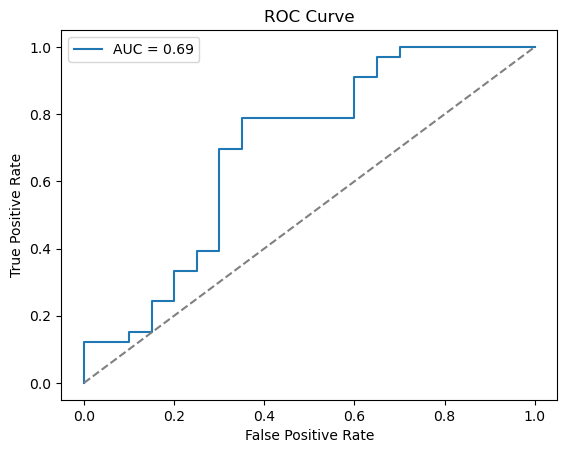

In [62]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

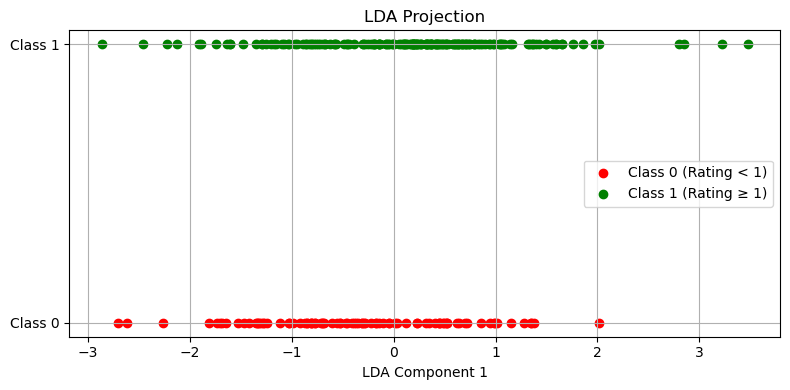

In [63]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import matplotlib.pyplot as plt

# Use the same X and y from before
lda = LDA(n_components=1)  # Only 1 component for binary classification
X_lda = lda.fit_transform(X, y)

# Plot
plt.figure(figsize=(8, 4))
plt.scatter(X_lda[y==0], [0]*sum(y==0), c='red', label='Class 0 (Rating < 1)')
plt.scatter(X_lda[y==1], [1]*sum(y==1), c='green', label='Class 1 (Rating ≥ 1)')
plt.title("LDA Projection")
plt.yticks([0, 1], ['Class 0', 'Class 1'])
plt.xlabel("LDA Component 1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [64]:
X

,p2_avg,p3_avg
10,2.354133,3.058938
11,3.230496,2.897318
12,3.557562,2.804925
13,3.937772,2.867321
14,3.803307,3.129456
...,...,...
335,0.968948,2.613087
336,0.957781,3.014075
337,0.818128,2.335739
338,1.757542,2.915198


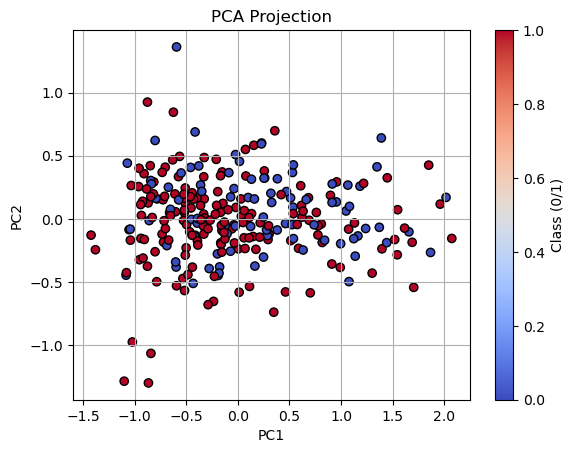

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X[['p2_avg','p3_avg']])

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("PCA Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.colorbar(label='Class (0/1)')
plt.show()


In [66]:
all_data_filtered_expanded

,p1_avg,tokens,tok_len,p2_avg,p3_avg,Rating_x,Rating_y,words,start_time,end_time
10,5.033718,"[tensor(508), tensor(340), tensor(338), tensor...",9,2.354133,3.058938,0.0,0.0,"who it's by? By Bill Martin,",50.0,55.0
11,4.789992,"[tensor(11), tensor(20000), tensor(290), tenso...",9,3.230496,2.897318,0.0,0.0,", Junior and John Archibald, illustrated",55.0,60.0
12,5.476334,"[tensor(18542), tensor(416), tensor(10174), te...",9,3.557562,2.804925,1.0,1.0,illustrated by Lewis Elhart. Ready? A,60.0,65.0
13,5.318196,"[tensor(317), tensor(1297), tensor(347), tenso...",9,3.937772,2.867321,1.0,1.0,A told B and B told C I'll,65.0,70.0
14,2.718074,"[tensor(1183), tensor(1826), tensor(345), tens...",9,3.803307,3.129456,1.0,1.0,'ll meet you at the top of the coconut,70.0,75.0
...,...,...,...,...,...,...,...,...,...,...
335,1.625698,"[tensor(13), tensor(220), tensor(679), tensor(...",15,0.968948,2.613087,1.0,1.0,". He is a famous tap dancer, right? Yeah.",1675.0,1680.0
336,1.946986,"[tensor(2141), tensor(345), tensor(892), tenso...",14,0.957781,3.014075,1.0,1.0,Do you think he's a famous tap dancer? The end.,1680.0,1685.0
337,1.925176,"[tensor(220), tensor(383), tensor(886), tensor...",10,0.818128,2.335739,1.0,1.0,The end... . That was a,1685.0,1690.0
338,2.871448,"[tensor(257), tensor(1049), tensor(1621), tens...",23,1.757542,2.915198,1.0,1.0,a great story huh? Another one. Oh. We're n...,1690.0,1695.0


In [67]:
repeated_p2_list = sum([[p2] * l for p2, l in zip(all_data_filtered_expanded['p2_avg'], all_data_filtered_expanded['tok_len'])], [])

In [68]:
repeated_p3_list = sum([[p3] * l for p3, l in zip(all_data_filtered_expanded['p3_avg'], all_data_filtered_expanded['tok_len'])], [])

In [69]:
assert all_data_filtered_expanded["tok_len"].sum() == len(repeated_p2_list)

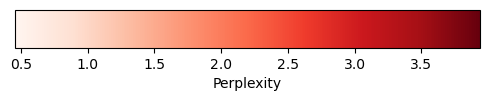

In [70]:
display_colored_sentences(list(all_data_filtered_expanded['tokens']), repeated_p2_list, tokenizer)

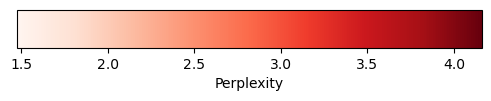

In [71]:
display_colored_sentences(list(all_data_filtered_expanded['tokens']), repeated_p3_list, tokenizer)

### Clusters

In [72]:
all_data_filtered_expanded["p2_avg"]

10     2.354133
11     3.230496
12     3.557562
13     3.937772
14     3.803307
         ...   
335    0.968948
336    0.957781
337    0.818128
338    1.757542
339    1.166844
Name: p2_avg, Length: 262, dtype: float64

In [73]:
from sklearn.decomposition import PCA
all_data_filtered.ffill(inplace=True)
X = np.column_stack((all_data_filtered_expanded["p2_avg"],all_data_filtered_expanded["p3_avg"]))

In [74]:
all_data_filtered_expanded

,p1_avg,tokens,tok_len,p2_avg,p3_avg,Rating_x,Rating_y,words,start_time,end_time
10,5.033718,"[tensor(508), tensor(340), tensor(338), tensor...",9,2.354133,3.058938,0.0,0.0,"who it's by? By Bill Martin,",50.0,55.0
11,4.789992,"[tensor(11), tensor(20000), tensor(290), tenso...",9,3.230496,2.897318,0.0,0.0,", Junior and John Archibald, illustrated",55.0,60.0
12,5.476334,"[tensor(18542), tensor(416), tensor(10174), te...",9,3.557562,2.804925,1.0,1.0,illustrated by Lewis Elhart. Ready? A,60.0,65.0
13,5.318196,"[tensor(317), tensor(1297), tensor(347), tenso...",9,3.937772,2.867321,1.0,1.0,A told B and B told C I'll,65.0,70.0
14,2.718074,"[tensor(1183), tensor(1826), tensor(345), tens...",9,3.803307,3.129456,1.0,1.0,'ll meet you at the top of the coconut,70.0,75.0
...,...,...,...,...,...,...,...,...,...,...
335,1.625698,"[tensor(13), tensor(220), tensor(679), tensor(...",15,0.968948,2.613087,1.0,1.0,". He is a famous tap dancer, right? Yeah.",1675.0,1680.0
336,1.946986,"[tensor(2141), tensor(345), tensor(892), tenso...",14,0.957781,3.014075,1.0,1.0,Do you think he's a famous tap dancer? The end.,1680.0,1685.0
337,1.925176,"[tensor(220), tensor(383), tensor(886), tensor...",10,0.818128,2.335739,1.0,1.0,The end... . That was a,1685.0,1690.0
338,2.871448,"[tensor(257), tensor(1049), tensor(1621), tens...",23,1.757542,2.915198,1.0,1.0,a great story huh? Another one. Oh. We're n...,1690.0,1695.0


In [75]:
#KMeans (assumes spherical clusters):
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0)
labels = kmeans.fit_predict(X)

/u/sebono/miniconda3/envs/.bewellenv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning



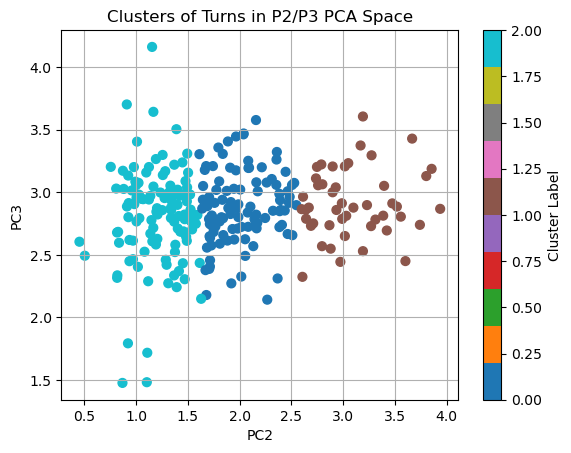

In [76]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap="tab10", s=40)
plt.title("Clusters of Turns in P2/P3 PCA Space")
plt.xlabel("PC2")
plt.ylabel("PC3")
plt.colorbar(label="Cluster Label")
plt.grid(True)
plt.show()

In [77]:
for cluster_id in np.unique(labels):
    print(f"\n--- Cluster {cluster_id} ---")
    indices = np.where(labels == cluster_id)[0][:10]
    print(all_data_filtered_expanded.iloc[indices]['words'].to_numpy())



--- Cluster 0 ---
[" who it's by? By Bill Martin," ' coconut tree..  Can you tell me what-'
 '-   Oh Jibo has a question. Jibo said tell him what letters.  Can you tell me what letters there are in'
 ' Awe thanks. Good job. Oh thank you.' '.  You want to have Jibo, hey J'
 ' A B to the top of the coconut tree' " tree.  Good job. What's next?"
 '?  A...  Chicka, chicka, boom, boom-   Boom'
 ' Boom, boom.   Here comes... '
 ' Will... Will there be enough room. Can you say that?']

--- Cluster 1 ---
[', Junior and John Archibald, illustrated'
 ' illustrated by Lewis Elhart. Ready? A' " A told B and B told C I'll"
 "'ll meet you at the top of the coconut" ' Jibo do you give kisses?   '
 '? Okay turn the page. And I and J and tag along K all'
 ' all on the way up the coconut tree.  Chicka- ' ' TJ. What makes'
 ' makes a boom sound' ' sound? ']

--- Cluster 2 ---
[' in the picture?  What letters are in the picture?  A.  A. Yeah. What else?  B. '
 ' B.  C.  C. Good job. A, B, C.  I like that

### Finding Signal

In [78]:
from utils import compute_dominance_per_spk, compute_significance

In [79]:
baselined_ppls_p2_spk = compute_dominance_per_spk(all_data_filtered["p2"], filtered_tokens_p1, matches, tokenizer)
baselined_ppls_p3_spk = compute_dominance_per_spk(all_data_filtered["p3"], filtered_tokens_p1, matches, tokenizer)

In [80]:
all_data_filtered_expanded

,p1_avg,tokens,tok_len,p2_avg,p3_avg,Rating_x,Rating_y,words,start_time,end_time
10,5.033718,"[tensor(508), tensor(340), tensor(338), tensor...",9,2.354133,3.058938,0.0,0.0,"who it's by? By Bill Martin,",50.0,55.0
11,4.789992,"[tensor(11), tensor(20000), tensor(290), tenso...",9,3.230496,2.897318,0.0,0.0,", Junior and John Archibald, illustrated",55.0,60.0
12,5.476334,"[tensor(18542), tensor(416), tensor(10174), te...",9,3.557562,2.804925,1.0,1.0,illustrated by Lewis Elhart. Ready? A,60.0,65.0
13,5.318196,"[tensor(317), tensor(1297), tensor(347), tenso...",9,3.937772,2.867321,1.0,1.0,A told B and B told C I'll,65.0,70.0
14,2.718074,"[tensor(1183), tensor(1826), tensor(345), tens...",9,3.803307,3.129456,1.0,1.0,'ll meet you at the top of the coconut,70.0,75.0
...,...,...,...,...,...,...,...,...,...,...
335,1.625698,"[tensor(13), tensor(220), tensor(679), tensor(...",15,0.968948,2.613087,1.0,1.0,". He is a famous tap dancer, right? Yeah.",1675.0,1680.0
336,1.946986,"[tensor(2141), tensor(345), tensor(892), tenso...",14,0.957781,3.014075,1.0,1.0,Do you think he's a famous tap dancer? The end.,1680.0,1685.0
337,1.925176,"[tensor(220), tensor(383), tensor(886), tensor...",10,0.818128,2.335739,1.0,1.0,The end... . That was a,1685.0,1690.0
338,2.871448,"[tensor(257), tensor(1049), tensor(1621), tens...",23,1.757542,2.915198,1.0,1.0,a great story huh? Another one. Oh. We're n...,1690.0,1695.0


In [81]:
from scipy.stats import spearmanr
import pandas as pd

cols = ['Rating_x','Rating_y']
# Perform correlation
stat, pval = spearmanr(all_data_filtered_expanded['p3_avg'], all_data_filtered_expanded[cols], nan_policy='omit')

# Extract just the relevant row (first row after the scalar)
correlation_vector = stat[0, 1:]
pval_vector = pval[0, 1:]

# Wrap into a DataFrame
corr_df = pd.DataFrame({
    "feature": cols,
    "spearman_r": correlation_vector,
    "p_value": pval_vector
})

# Sort by absolute correlation
corr_df["abs_r"] = corr_df["spearman_r"].abs()
corr_df = corr_df.sort_values("abs_r", ascending=False)

corr_df[["feature", "spearman_r", "p_value"]]


,feature,spearman_r,p_value
1,Rating_y,-0.169418,0.005977
0,Rating_x,-0.159212,0.009845


In [82]:
X = all_data_filtered_expanded[cols].fillna(0)
y = all_data_filtered_expanded['p3_avg']

In [83]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

rf_importances = pd.DataFrame({
    "feature": cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

print(rf_importances)

    feature  importance
1  Rating_y    0.594891
0  Rating_x    0.405109


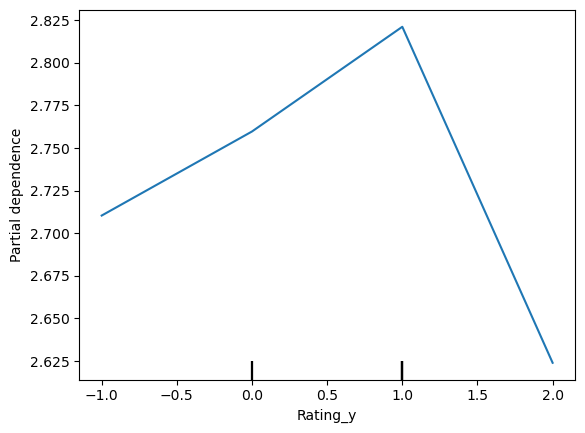

In [84]:
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(rf, X, ['Rating_y'])
plt.show()


In [85]:
from sklearn.model_selection import train_test_split
# Features and target
all_data_filtered_expanded.dropna(inplace=True)
X = all_data_filtered_expanded[cols]
y = all_data_filtered_expanded["p3_avg"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)